Notebook for generating plots after benching french STT models

In [72]:
import os
import json
import pandas as pd
import numpy as np

from asr_benchmark.visualization.plots import prepare_data, plot_violin_df, plot_wer_df, plot_bar_df
from asr_benchmark.utils.visualize import load_data

pd.set_option("future.no_silent_downcasting", True)

/tmp/ipykernel_110313/2585884945.py:9: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option("future.no_silent_downcasting", True)


In [73]:
INPUT_FOLDER = "local_bench"
OUTPUT_FOLDER = "local_plots"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)
df = pd.DataFrame(load_data(INPUT_FOLDER))

  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:01<00:00,  8.50it/s]


In [74]:
df["dataset"] = df["dataset"].replace({
    "YouTubeFr_split6": "YouTube",
    "TEDX_fr": "TEDx",
    "MLS_Facebook_french": "MLS",
    "Voxpopuli": "VoxPopuli"
})
print(df["dataset"].unique())
datasets = ['CommonVoice', 'MLS', 'SUMM-RE', 'TEDx', 'YouTube']
# datasets = ['CommonVoice', 'MLS', 'SUMM-RE', 'VoxPopuli', 'TEDx', 'YouTube']
all_models = df["model"].unique()
print(all_models)
models = all_models
models = [
        'whisper-large-v3-turbo', 
        'nvidia/canary-180m-flash',
        'nvidia/stt-fr-fastconformer-hybrid-large-pc', 
        'bofenghuang/stt-fr-fastconformer-hybrid-large', 
        'linagora/linto-stt-fr-fastconformer',
        'linagora/linto-stt-fr-fastconformer-pc',
        'nvidia/canary-1b-v2',
        'nvidia/parakeet-tdt-0.6b-v3']
df = df[
    (df['model'].isin(models))
    & ((df["decoder"] == "rnnt") | (df["decoder"].isnull()))
    & (df["dataset"].isin(datasets))
        ]


<StringArray>
['CommonVoice', 'MLS', 'SUMM-RE', 'TEDx', 'YouTube', 'VoxPopuli']
Length: 6, dtype: str
<StringArray>
[                       'whisper-large-v3-turbo',
                              'whisper-large-v3',
 'bofenghuang/stt-fr-fastconformer-hybrid-large',
        'linagora/linto-stt-fr-fastconformer-pc',
           'linagora/linto-stt-fr-fastconformer',
                      'nvidia/canary-180m-flash',
                           'nvidia/canary-1b-v2',
                              'nvidia/canary-1b',
                   'nvidia/parakeet-tdt-0.6b-v3',
   'nvidia/stt-fr-fastconformer-hybrid-large-pc']
Length: 10, dtype: str


In [75]:
from asr_benchmark.visualization.table import plot_wer_table, prepare_model_name, reorder_wer_pivot

# df['model'] = df.apply(lambda row: row['model']+ "\n" + row['decoder'].upper() if pd.notna(row['decoder']) else row['model'], axis=1)
wer_pivot = df.pivot(index='model', columns='dataset', values='wer')

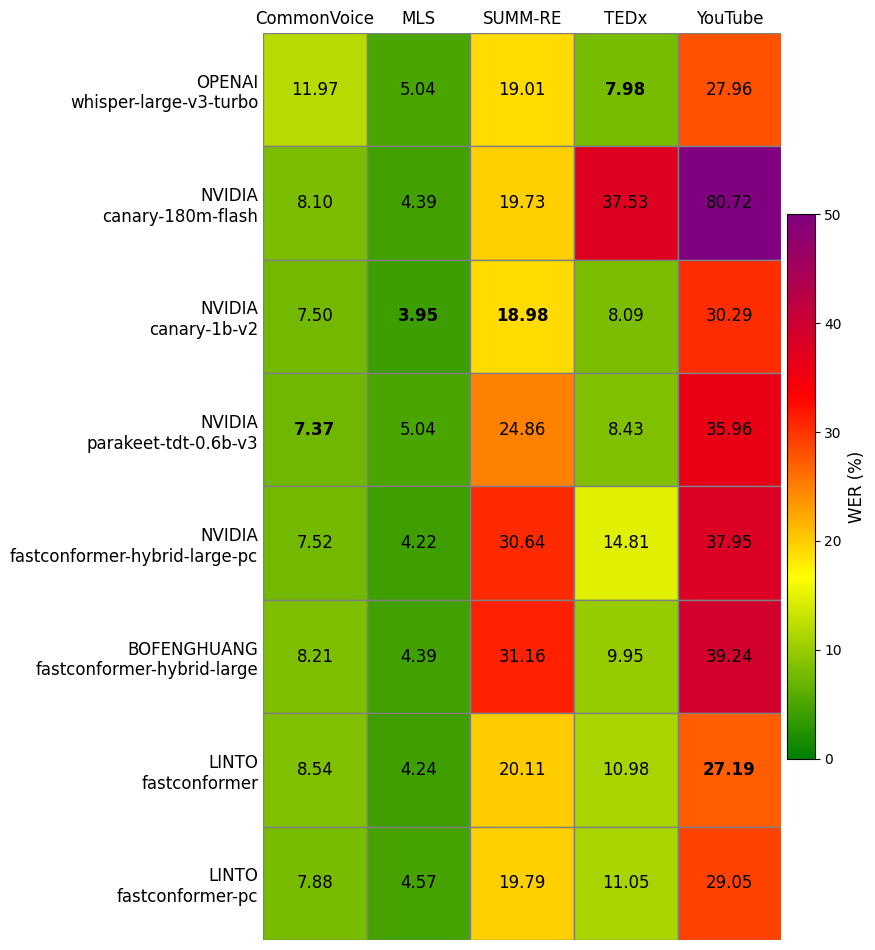

In [76]:
wer_pivot.index = [prepare_model_name(name) for name in wer_pivot.index]
wer_pivot = reorder_wer_pivot(wer_pivot)
plot_wer_table(wer_pivot, output_filename=os.path.join(OUTPUT_FOLDER, "wer_table.png"))

In [77]:
df = pd.DataFrame(load_data(INPUT_FOLDER, casepunc=True))

df["dataset"] = df["dataset"].replace({
    "YouTubeFr_split6": "YouTube",
    "TEDX_fr": "TEDx",
    "MLS_Facebook_french": "MLS",
    "Voxpopuli": "VoxPopuli"
})
print(df["dataset"].unique())
datasets = ['CommonVoice', 'MLS', 'SUMM-RE', 'VoxPopuli', 'TEDx', 'YouTube']
all_models = df["model"].unique()
print(all_models)
models = all_models
models = [
        'whisper-large-v3-turbo', 
        'nvidia/canary-180m-flash',
        'nvidia/stt-fr-fastconformer-hybrid-large-pc', 
        'bofenghuang/stt-fr-fastconformer-hybrid-large', 
        'linagora/linto-stt-fr-fastconformer',
        'linagora/linto-stt-fr-fastconformer-pc',
        'nvidia/canary-1b-v2',
        'nvidia/parakeet-tdt-0.6b-v3']
df = df[
    (df['model'].isin(models))
    & ((df["decoder"] == "rnnt") | (df["decoder"].isnull()))
]

100%|██████████| 13/13 [00:01<00:00,  9.67it/s]

<StringArray>
['CommonVoice', 'TEDx', 'YouTube', 'VoxPopuli']
Length: 4, dtype: str
<StringArray>
[                       'whisper-large-v3-turbo',
                              'whisper-large-v3',
 'bofenghuang/stt-fr-fastconformer-hybrid-large',
        'linagora/linto-stt-fr-fastconformer-pc',
           'linagora/linto-stt-fr-fastconformer',
                      'nvidia/canary-180m-flash',
                           'nvidia/canary-1b-v2',
                              'nvidia/canary-1b',
                   'nvidia/parakeet-tdt-0.6b-v3',
   'nvidia/stt-fr-fastconformer-hybrid-large-pc']
Length: 10, dtype: str


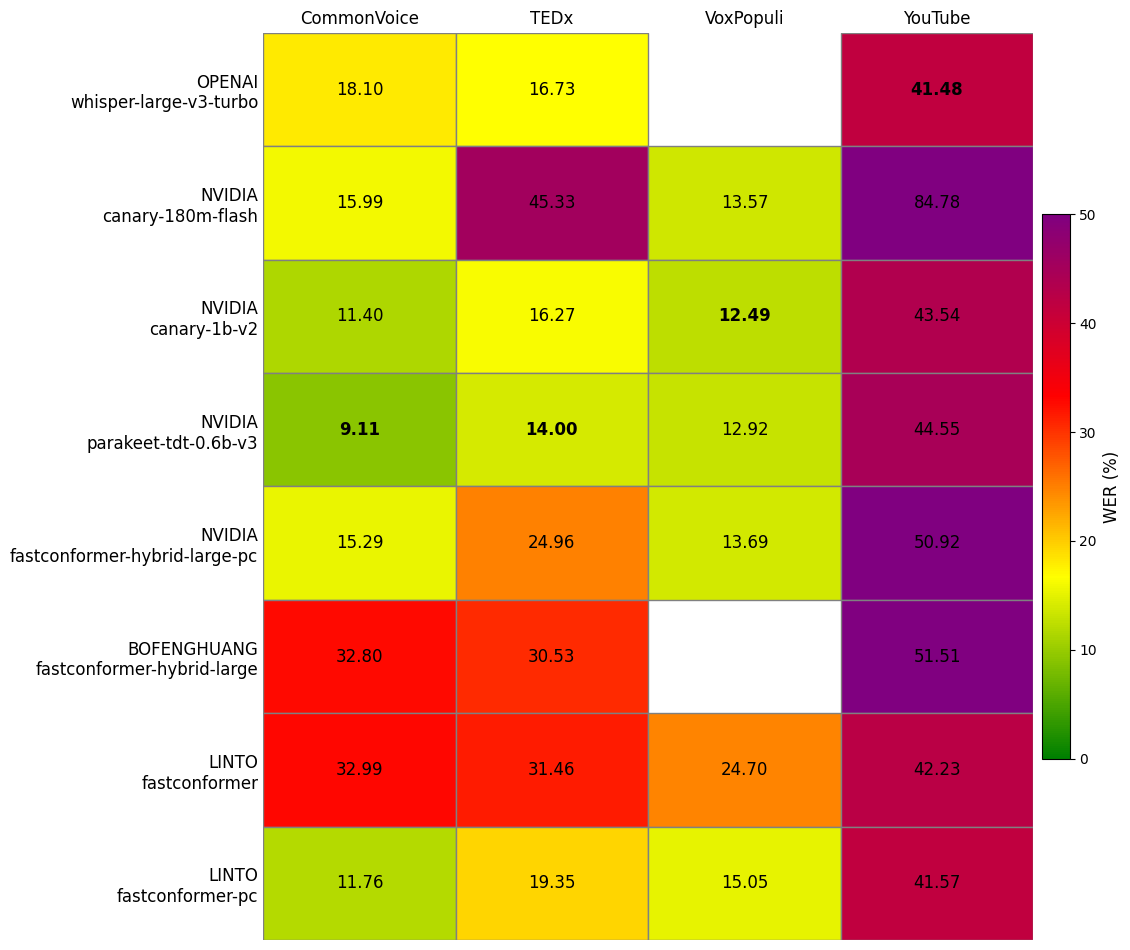

In [78]:
# df['model'] = df.apply(lambda row: row['model']+ "\n" + row['decoder'].upper() if pd.notna(row['decoder']) else row['model'], axis=1)
wer_pivot = df.pivot(index='model', columns='dataset', values='wer')
wer_pivot.index = [prepare_model_name(name) for name in wer_pivot.index]
wer_pivot = reorder_wer_pivot(wer_pivot)
plot_wer_table(wer_pivot, output_filename=os.path.join(OUTPUT_FOLDER, "wer_table_casepunc.png"))